<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
brain_mri = nib.load('/content/drive/MyDrive/Colab Notebooks/IXI662-Guys-1120-T1.nii.gz')

In [ ]:
brain_mri_data = brain_mri.get_fdata()

In [ ]:
affine = brain_mri.affine
shape = brain_mri.shape

In [ ]:
print(affine)

[[ 1.89821944e-02 -2.72075552e-03  1.19975281e+00 -9.06798553e+01]
 [-9.27821696e-01  1.32986516e-01  2.45456006e-02  1.02829445e+02]
 [ 1.33014351e-01  9.28015888e-01  5.71511449e-11 -1.14823784e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [ ]:
print(shape)

(256, 256, 150)


In [ ]:
nib.aff2axcodes(affine)

('P', 'S', 'R')

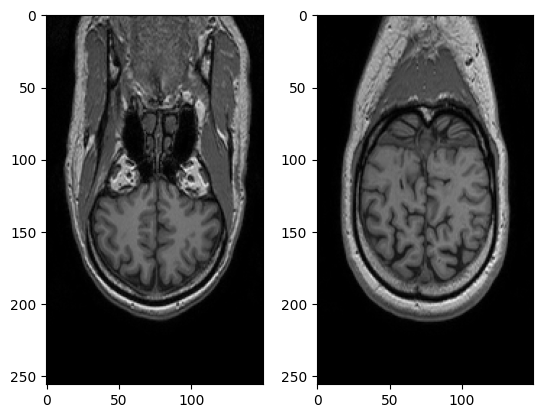

In [ ]:
fig, axis = plt.subplots(1, 2)
axis[0].imshow(brain_mri_data[70, :, :], cmap = 'gray')
axis[1].imshow(brain_mri_data[196, :, :], cmap = 'gray')

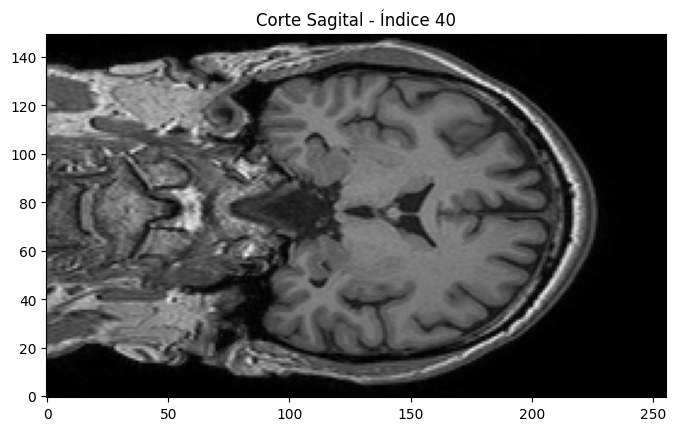

In [ ]:
# Extraer un corte sagital, índice 40
corte_sagital = brain_mri_data[120, :, :]

plt.figure(figsize=(8, 6))
plt.imshow(corte_sagital.T, cmap = 'gray', origin = 'lower')
plt.title("Corte Sagital - Índice 40")
plt.show()

In [ ]:
from skimage.filters import threshold_otsu

In [ ]:
umbral = threshold_otsu(corte_sagital)

In [ ]:
corte_binario = corte_sagital>umbral

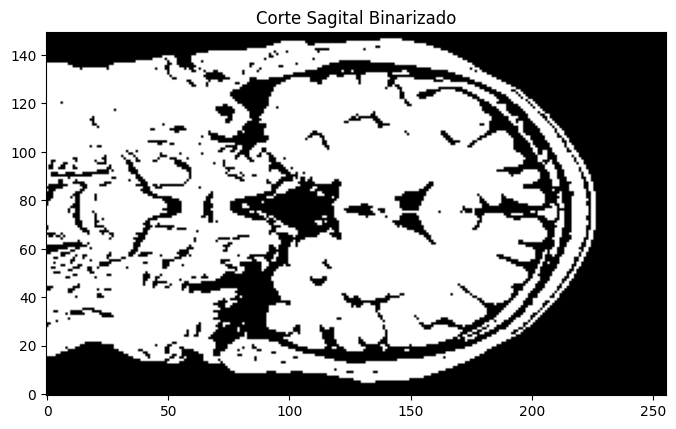

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(corte_binario.T, cmap = 'gray', origin = 'lower')
plt.title("Corte Sagital Binarizado")
plt.show()

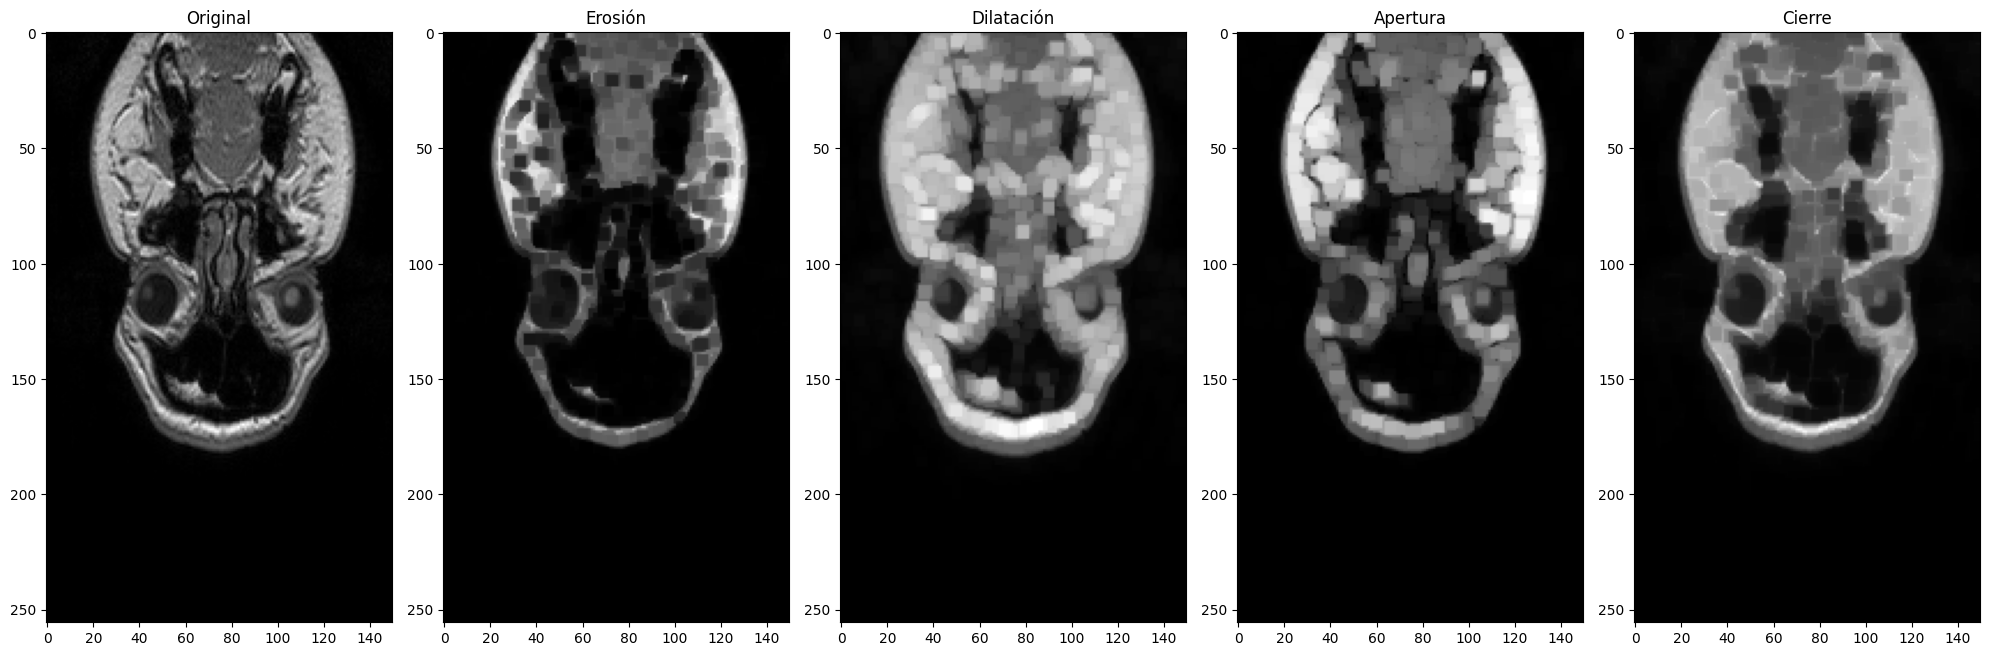

In [ ]:
import numpy as np
import cv2

slice_index = 40
image_slice = brain_mri_data[slice_index,:,:]

# Normalizar imagen
image_slice_normalized = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Definir kernel
kernel = np.ones((5,5), np.uint8)

# Aplicar operaciones morfológicas
erosion = cv2.erode(image_slice_normalized, kernel, iterations=1)
dilation = cv2.dilate(image_slice_normalized, kernel, iterations=1)
opening = cv2.morphologyEx(image_slice_normalized, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image_slice_normalized, cv2.MORPH_CLOSE, kernel)

# Visualizar resultados
fig, axs = plt.subplots(1, 5, figsize=(20,10))

axs[0].imshow(image_slice_normalized, cmap = 'gray')
axs[0].set_title('Original')

axs[1].imshow(erosion, cmap = 'gray')
axs[1].set_title('Erosión')

axs[2].imshow(dilation, cmap = 'gray')
axs[2].set_title('Dilatación')

axs[3].imshow(opening, cmap = 'gray')
axs[3].set_title('Apertura')

axs[4].imshow(closing, cmap = 'gray')
axs[4].set_title('Cierre')

plt.tight_layout()
plt.show()

(-0.5, 149.5, 255.5, -0.5)

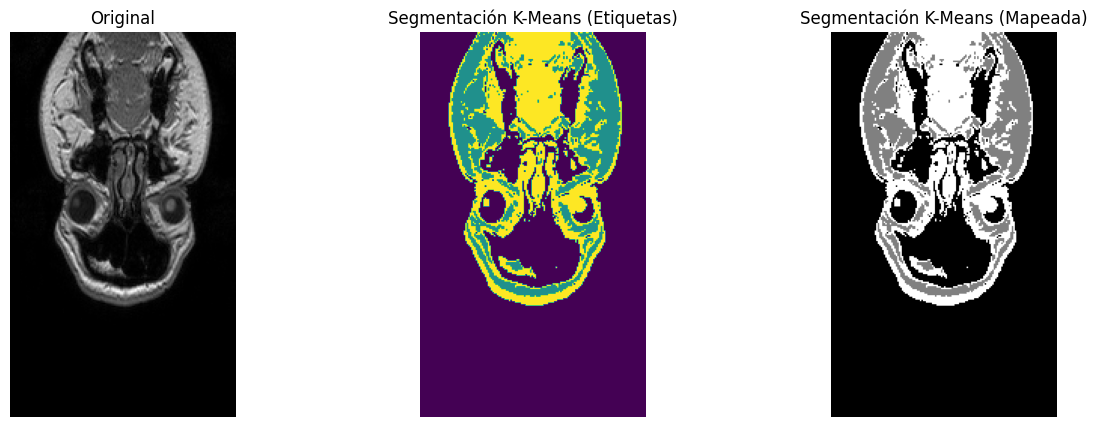

In [ ]:
# Segmentación
from sklearn.cluster import KMeans
import cv2
import numpy as np
import matplotlib.pyplot as plt

slice_index = 40
image_slice = brain_mri_data[slice_index,:,:]

# Normalizar imagen
image_slice_normalized = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Aplanar la imagen para k-means
pixels = image_slice_normalized.flatten().reshape(-1, 1)

# Aplicar k-means
kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(pixels)

segmented_image = kmeans.labels_.reshape(image_slice_normalized.shape)

segmented_image_mapped = (segmented_image *(255// kmeans.n_clusters)).astype(np.uint8)

# Visualizar
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(image_slice_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(segmented_image, cmap = 'viridis')
axs[1].set_title('Segmentación K-Means (Etiquetas)')
axs[1].axis("off")

axs[2].imshow(segmented_image_mapped, cmap = 'gray')
axs[2].set_title('Segmentación K-Means (Mapeada)')
axs[2].axis("off")



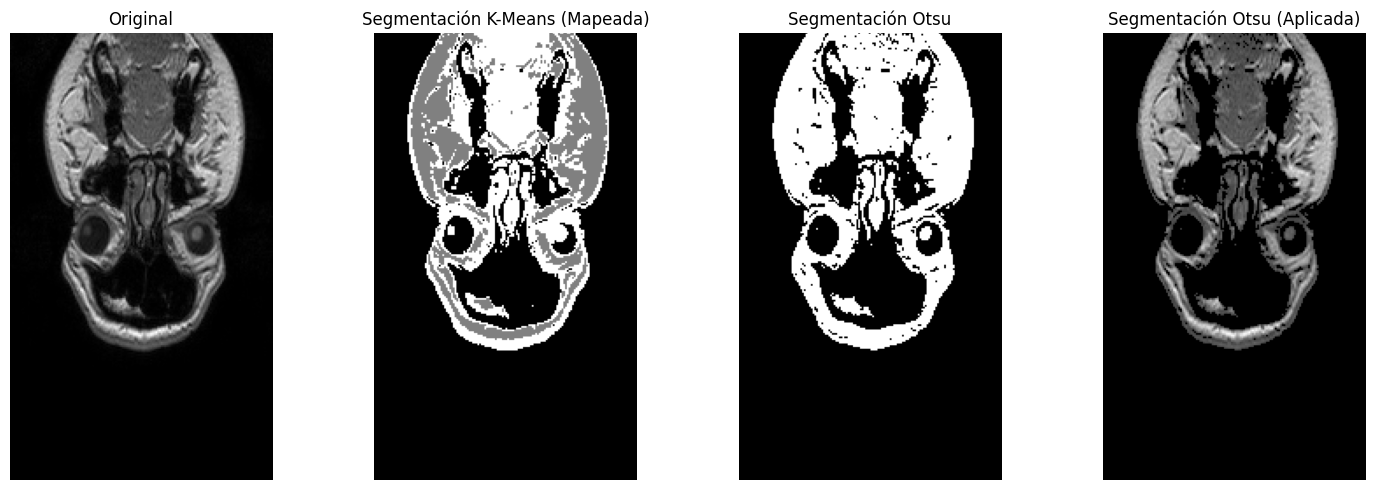

In [ ]:
from skimage.filters import threshold_otsu

slice_index = 40
image_slice = brain_mri_data[slice_index,:,:]

# Normalizar imagen
image_slice_normalized = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Aplanar la imagen para k-means
pixels = image_slice_normalized.flatten().reshape(-1, 1)

# Aplicar k-means
kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(pixels)

segmented_image = kmeans.labels_.reshape(image_slice_normalized.shape)

segmented_image_mapped = (segmented_image *(255// kmeans.n_clusters)).astype(np.uint8)

# Segmentar con Otsu
otsu_threshold = threshold_otsu(image_slice_normalized)
otsu_segmented = image_slice_normalized>otsu_threshold

# Visualizar
fig, axs = plt.subplots(1, 4, figsize=(15,5))

axs[0].imshow(image_slice_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(segmented_image_mapped, cmap = 'gray')
axs[1].set_title('Segmentación K-Means (Mapeada)')
axs[1].axis("off")

axs[2].imshow(otsu_segmented, cmap = 'gray')
axs[2].set_title('Segmentación Otsu')
axs[2].axis("off")

axs[3].imshow(image_slice_normalized*otsu_segmented, cmap = 'gray')
axs[3].set_title('Segmentación Otsu (Aplicada)')
axs[3].axis("off")

plt.tight_layout()
plt.show()

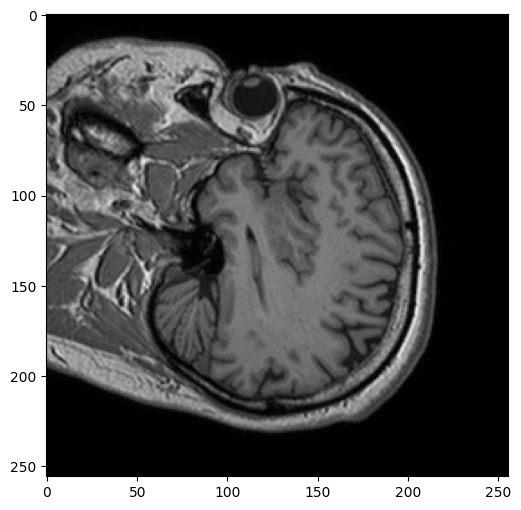

In [ ]:
image_brain = brain_mri_data[:, :, 45]
image_brain_normalized = cv2.normalize(image_brain, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(image_brain_normalized, cmap = 'gray')
plt.show()

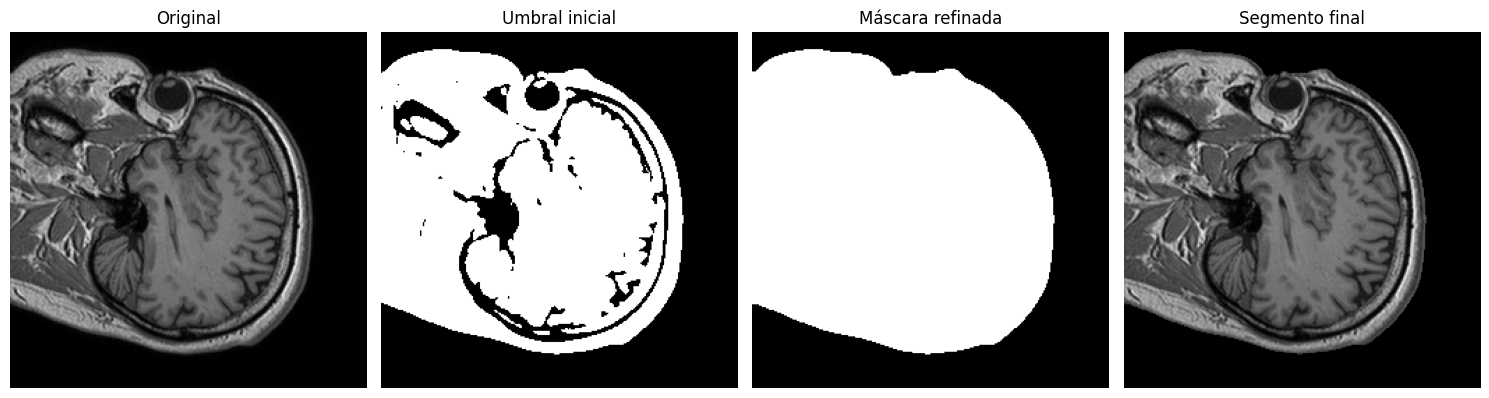

In [ ]:
image_brain = brain_mri_data[:, :, 45]
image_brain_normalized = cv2.normalize(image_brain, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Suavizar la imagen para reducir el ruido
image_blurred = cv2.GaussianBlur(image_brain_normalized, (5,5), 0)

# Aplicar un umbral para segmentar el cerebro
_, brain_threshold = cv2.threshold(image_blurred, 50, 255, cv2.THRESH_BINARY)

# Aplicar operaciones morfológicas
kernel = np.ones((5,5), np.uint8)
brain_cleaned = cv2.morphologyEx(brain_threshold, cv2.MORPH_OPEN, kernel)
brain_cleaned = cv2.morphologyEx(brain_threshold, cv2.MORPH_CLOSE, kernel)

contours,_= cv2.findContours(brain_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_largest = np.zeros_like(brain_cleaned)
if contours:
  largest_contour = max(contours, key=cv2.contourArea)
  cv2.drawContours(mask_largest, [largest_contour], -1, 255, thickness=cv2.FILLED)

# Aplicar la máscara al corte original
segmento_cerebro = cv2.bitwise_and(image_brain_normalized, image_brain_normalized, mask = mask_largest)

# Visualizar
fig, axs = plt.subplots(1, 4, figsize=(15,5))

axs[0].imshow(image_brain_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(brain_threshold, cmap = 'gray')
axs[1].set_title('Umbral inicial')
axs[1].axis("off")

axs[2].imshow(mask_largest, cmap = 'gray')
axs[2].set_title('Máscara refinada')
axs[2].axis("off")

axs[3].imshow(segmento_cerebro, cmap = 'gray')
axs[3].set_title('Segmento final')
axs[3].axis("off")

plt.tight_layout()
plt.show()

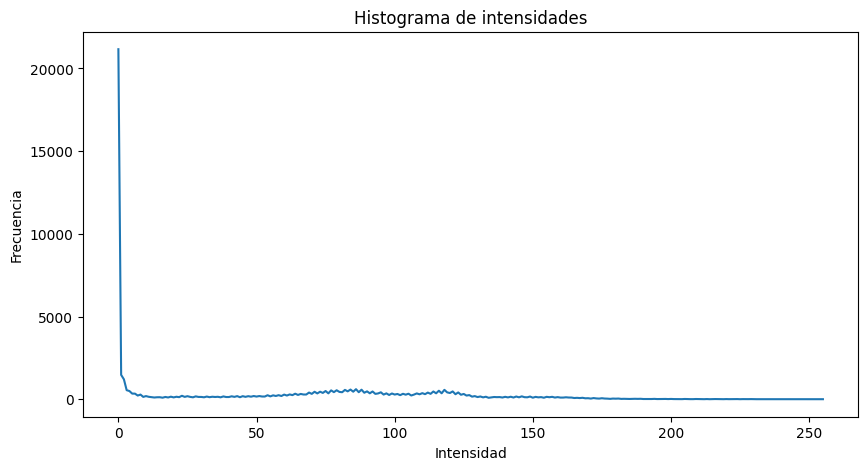

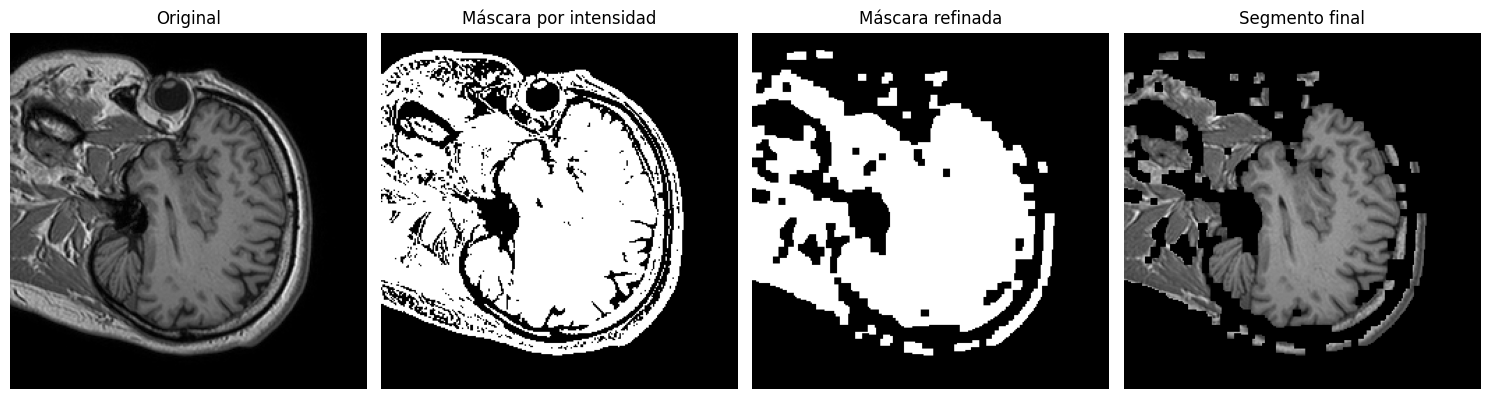

In [ ]:
image_brain = brain_mri_data[:, :, 45]
image_brain_normalized = cv2.normalize(image_brain, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Calcular el histograma
hist = cv2.calcHist([image_brain_normalized], [0], None, [256], [0, 256])

#Visualizar el histograma
plt.figure(figsize=(10, 5))
plt.plot(hist)
plt.title("Histograma de intensidades")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.show()

# Seleccionar un rango de intensidades específicos para el cerebro
lower_bound = 50
upper_bound = 150

mask_intensity = cv2.inRange(image_brain_normalized, lower_bound, upper_bound)
kernel = np.ones((5,5), np.uint8)
mask_cleaned = cv2.morphologyEx(mask_intensity, cv2.MORPH_OPEN, kernel)
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_CLOSE, kernel)

segmento_cerebro = cv2.bitwise_and(image_brain_normalized, image_brain_normalized, mask = mask_cleaned)

# Visualizar
fig, axs = plt.subplots(1, 4, figsize=(15,5))

axs[0].imshow(image_brain_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(mask_intensity, cmap = 'gray')
axs[1].set_title('Máscara por intensidad')
axs[1].axis("off")

axs[2].imshow(mask_cleaned, cmap = 'gray')
axs[2].set_title('Máscara refinada')
axs[2].axis("off")

axs[3].imshow(segmento_cerebro, cmap = 'gray')
axs[3].set_title('Segmento final')
axs[3].axis("off")

plt.tight_layout()
plt.show()

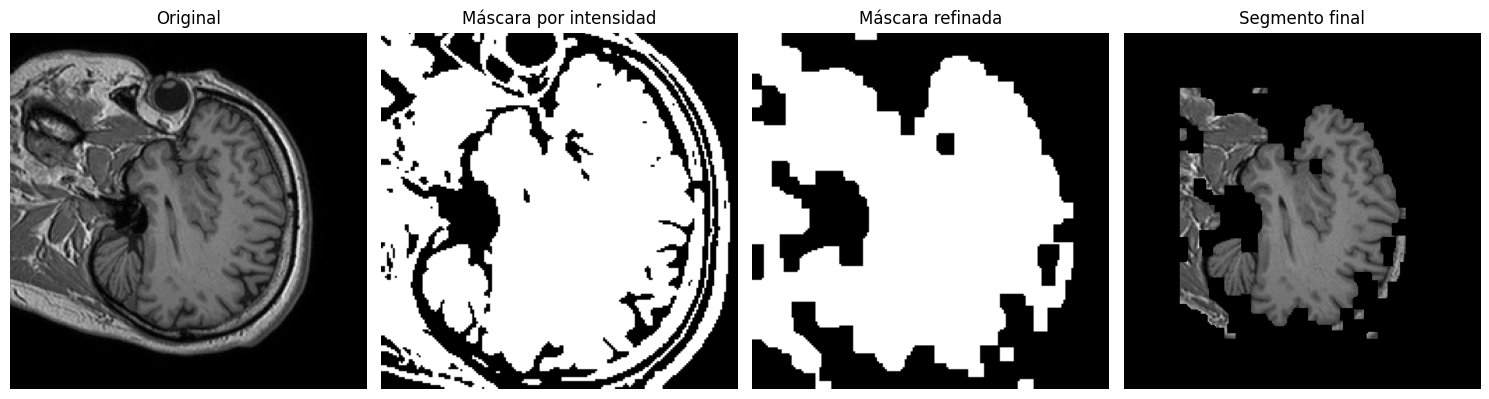

In [ ]:
#Definir una región de interés
x_start, x_end = 40, 220
y_start, y_end = 40, 220

# Recortar la región de interés
roi_brain = image_brain_normalized[y_start:y_end, x_start:x_end]

roi_blurred = cv2.GaussianBlur(roi_brain, (5,5), 0)

lower_bound = 60
upper_bound = 140

roi_mask_intensity = cv2.inRange(roi_blurred, lower_bound, upper_bound)

#Aplicar op morf
kernel = np.ones((7,7), np.uint8)
roi_mask_cleaned = cv2.morphologyEx(roi_mask_intensity, cv2.MORPH_OPEN, kernel)
roi_mask_cleaned = cv2.morphologyEx(roi_mask_cleaned, cv2.MORPH_CLOSE, kernel)

# Volver a colocar la ROI procesada en una máscara del tamaño original
final_mask = np.zeros_like(image_brain_normalized)
final_mask[y_start:y_end, x_start:x_end] = roi_mask_cleaned

# Aplicar la máscara al corte original
segmento_cerebro_final = cv2.bitwise_and(image_brain_normalized, image_brain_normalized, mask = final_mask)

# Visualizar
fig, axs = plt.subplots(1, 4, figsize=(15,5))

axs[0].imshow(image_brain_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(roi_mask_intensity, cmap = 'gray')
axs[1].set_title('Máscara por intensidad')
axs[1].axis("off")

axs[2].imshow(roi_mask_cleaned, cmap = 'gray')
axs[2].set_title('Máscara refinada')
axs[2].axis("off")

axs[3].imshow(segmento_cerebro_final, cmap = 'gray')
axs[3].set_title('Segmento final')
axs[3].axis("off")

plt.tight_layout()
plt.show()

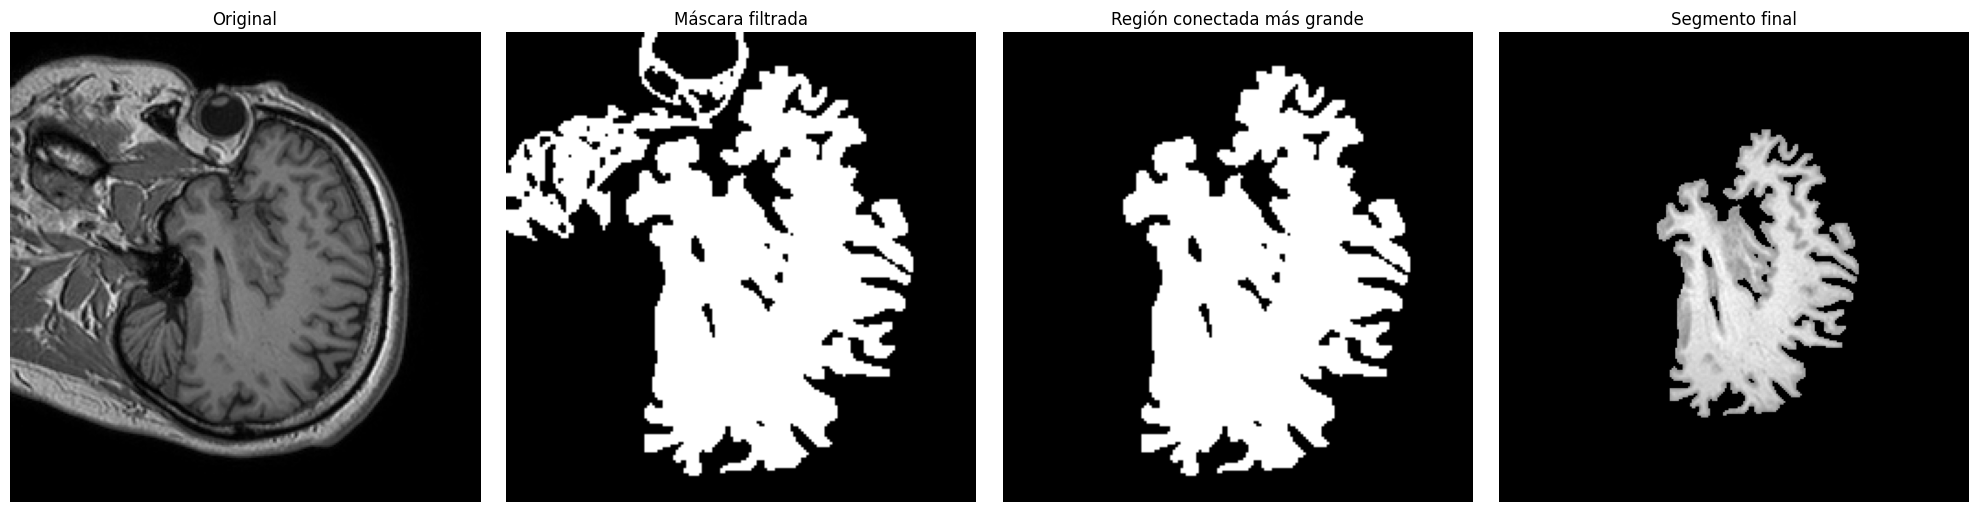

In [ ]:
lower_bound = 80
upper_bound = 150

roi_mask_intensity = cv2.inRange(roi_blurred, lower_bound, upper_bound)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(roi_mask_intensity, connectivity=8)

min_area = 1000
mask_filtered = np.zeros_like(labels, dtype = np.uint8)
for label in range(1, num_labels):
  if stats[label, cv2.CC_STAT_AREA] >= min_area:
    mask_filtered[labels == label] = 255

largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
mask_largest = np.zeros_like(mask_filtered, dtype=np.uint8)
mask_largest[labels == largest_label] = 255

mask_full_size = np.zeros_like(image_brain_normalized, dtype=np.uint8)
mask_full_size[y_start:y_end, x_start:x_end] = mask_largest

segmento_cerebro_final_refinado = cv2.bitwise_and(image_brain_normalized, image_brain_normalized, mask = mask_full_size)

# Visualizar
fig, axs = plt.subplots(1, 4, figsize=(20,5))

axs[0].imshow(image_brain_normalized, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(mask_filtered, cmap = 'gray')
axs[1].set_title('Máscara filtrada')
axs[1].axis("off")

axs[2].imshow(mask_largest, cmap = 'gray')
axs[2].set_title('Región conectada más grande')
axs[2].axis("off")

axs[3].imshow(segmento_cerebro_final_refinado, cmap = 'gray')
axs[3].set_title('Segmento final')
axs[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
area_segmentada = np.sum(mask_largest>0)
print(f"Area segmentada: {area_segmentada} pixeles")

Area segmentada: 9910 pixeles


In [ ]:
intensidad_promedio = np.mean(segmento_cerebro_final_refinado[segmento_cerebro_final_refinado > 0])
print(f"Intensidad promedio del cerebro segmentado: {intensidad_promedio}")

Intensidad promedio del cerebro segmentado: 105.45287588294651


In [ ]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.1/92.1 MB 7.4 MB/s eta 0:00:00


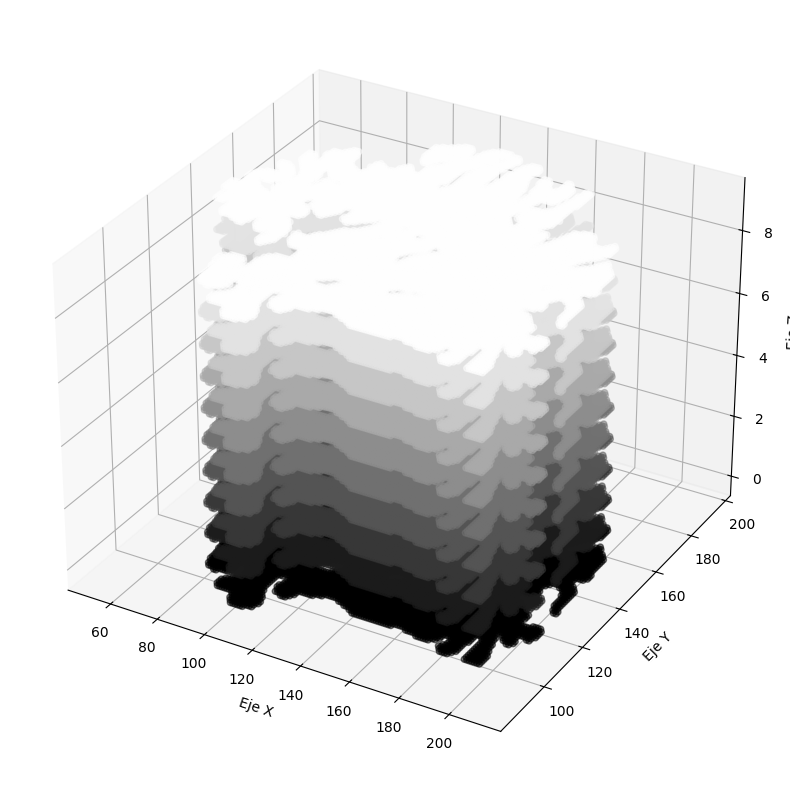

In [ ]:
volume_3d = np.expand_dims(mask_full_size, axis=2)
volume_3d = np.repeat(volume_3d, 10, axis = 2)

# Coordenadas donde el volumen tiene valores mayores a 0
x, y, z = np.where(volume_3d > 0)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(x, y, z, c=z, cmap = 'gray', marker = 'o', alpha = 0.5)
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
ax.set_zlabel("Eje Z")
plt.show()

<ipython-input-51-65cb42ff5be4>:14: UserWarning: The following kwargs were not used by contour: 'linewidth'
  axs[1].contour(mask_full_size, colors = 'red', linewidth = 0.5)


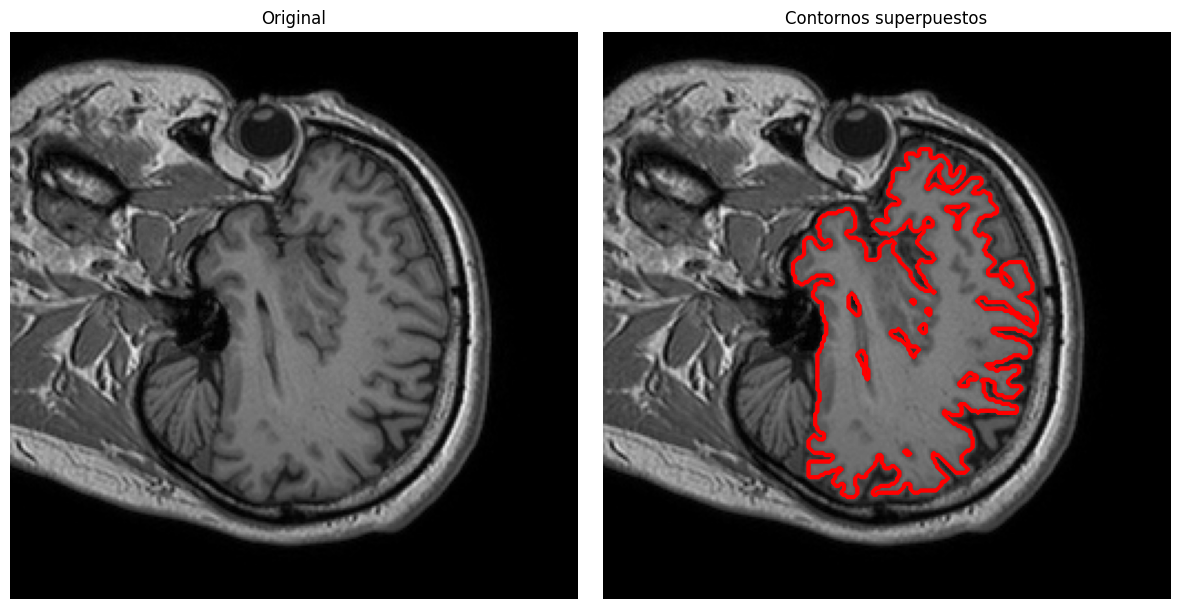

In [ ]:
imagen_original = image_brain_normalized
contours, _ = cv2.findContours(mask_full_size, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_image = np.zeros_like(imagen_original)

cv2.drawContours(contour_image, contours, -1, (255, 255, 255), thickness=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(imagen_original, cmap = 'gray')
axs[0].set_title('Original')
axs[0].axis("off")

axs[1].imshow(imagen_original, cmap = 'gray')
axs[1].contour(mask_full_size, colors = 'red', linewidth = 0.5)
axs[1].set_title('Contornos superpuestos')
axs[1].axis("off")

plt.tight_layout()
plt.show()

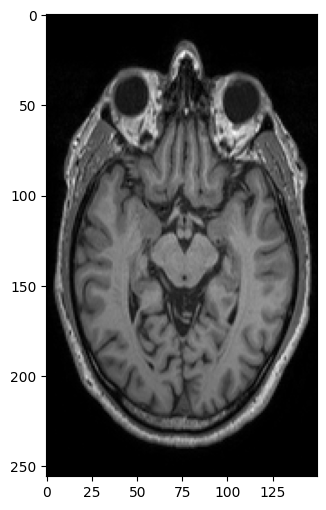

In [ ]:
img_r = brain_mri_data[:, 120, :]
plt.figure(figsize=(8, 6))
plt.imshow(img_r, cmap = 'gray')
plt.show()

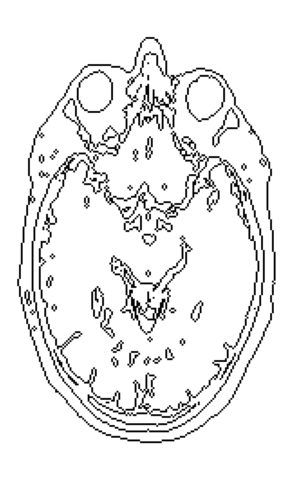

In [ ]:
image_normalized = cv2.normalize(img_r, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, binary_mask = cv2.threshold(image_normalized, 50, 255, cv2.THRESH_BINARY)
contours, hierachy = cv2.findContours(binary_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
background = np.ones_like(binary_mask)*255
contour_image = cv2.drawContours(background, contours, -1, (0), thickness=1)

plt.figure(figsize=(8, 6))
plt.imshow(contour_image, cmap = 'gray')
plt.axis("off")
plt.show()

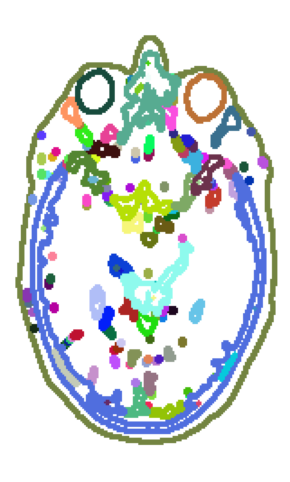

In [ ]:
contour_image_color = np.ones((*binary_mask.shape, 3), dtype=np.uint8)*255
for contour in contours:
  color = tuple(np.random.randint(0, 255, size = 3).tolist())
  cv2.drawContours(contour_image_color, [contour], -1, color, thickness = 2)

plt.figure(figsize=(8, 6))
plt.imshow(contour_image_color)
plt.axis("off")
plt.show()

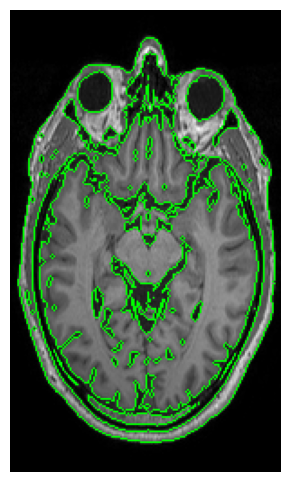

In [ ]:
overlay = image_normalized.copy()
overlay = cv2.cvtColor(overlay, cv2.COLOR_GRAY2BGR)

for contour in contours:
  cv2.drawContours(overlay, [contour], -1, (0,255, 0), thickness=1)
plt.figure(figsize=(8, 6))
plt.imshow(overlay)
plt.axis("off")
plt.show()